In [37]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

data_path = 'data_output_large_critical_rw'

In [38]:
with open(os.path.join(data_path, 'graph.json'), 'r') as f:
    graph = json.load(f)

directed = graph.get("directed", False)

def make_edge(u, v):
    """Directed edge = ordered tuple; undirected edge = frozenset."""
    return (u, v) if directed else frozenset((u, v))

true_edges = set()
for node, neighbors in graph['adjacency'].items():
    for neighbor in neighbors:
        true_edges.add(make_edge(int(node), int(neighbor)))

kind = "directed" if directed else "undirected"
print(f"Graph type: {kind}")
print(f"Number of nodes: {len(graph['nodes'])}")
print(f"Number of unique {kind} edges: {len(true_edges)}")

Number of nodes: 342
Number of unique undirected edges: 341


In [39]:
def load_trajectories(filepath):
    """Parse trajectory file, returning list of path-node lists (the part after <end_goal>)."""
    trajectories = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('<end_goal>')
            if len(parts) < 2:
                continue
            path_tokens = parts[1].strip().split()
            trajectories.append([int(t) for t in path_tokens])
    return trajectories

train_trajs = load_trajectories(os.path.join(data_path, 'train.txt'))
val_trajs = load_trajectories(os.path.join(data_path, 'val.txt'))
test_trajs = load_trajectories(os.path.join(data_path, 'test.txt'))

all_trajs = train_trajs + val_trajs + test_trajs

print(f"Train trajectories: {len(train_trajs)}")
print(f"Val trajectories:   {len(val_trajs)}")
print(f"Test trajectories:  {len(test_trajs)}")
print(f"Total trajectories: {len(all_trajs)}")

Train trajectories: 80000
Val trajectories:   10000
Test trajectories:  10000
Total trajectories: 100000


/tmp/ipykernel_3432791/1319479294.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


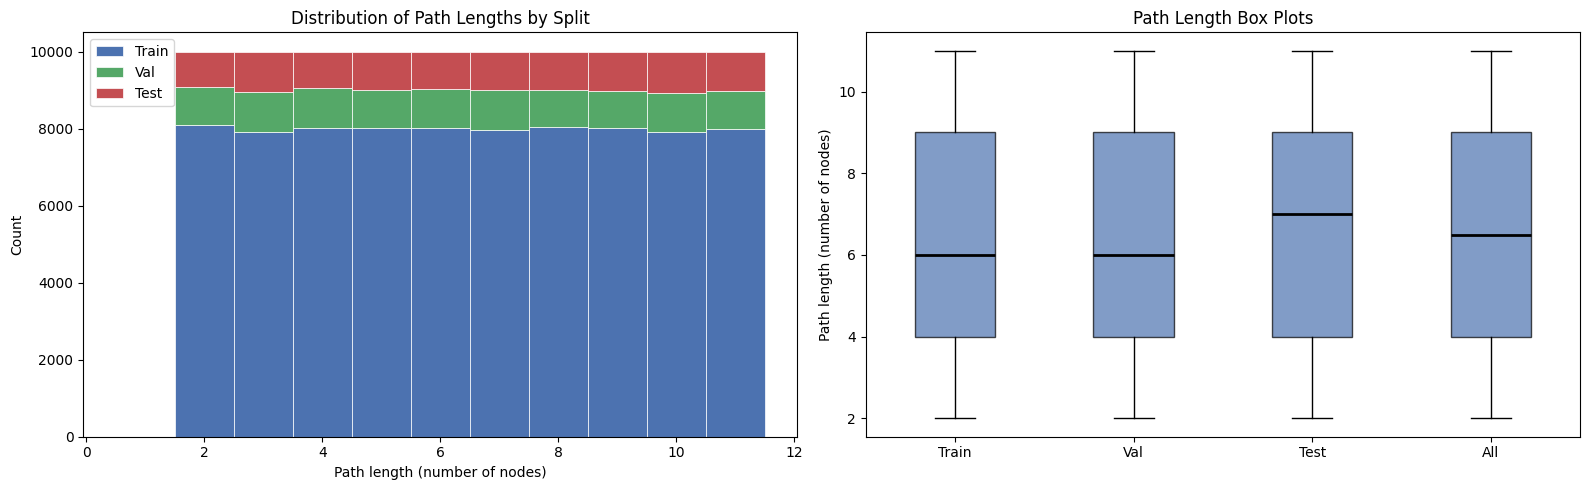

Path length stats (all splits):
  Min: 2, Max: 11, Mean: 6.50, Median: 6.5


In [40]:
# --- Histogram of path lengths ---
train_lengths = [len(t) for t in train_trajs]
val_lengths = [len(t) for t in val_trajs]
test_lengths = [len(t) for t in test_trajs]
all_lengths = [len(t) for t in all_trajs]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked histogram by split
max_len = max(all_lengths)
bins = np.arange(1, max_len + 2) - 0.5

axes[0].hist(
    [train_lengths, val_lengths, test_lengths],
    bins=bins,
    stacked=True,
    label=['Train', 'Val', 'Test'],
    color=['#4C72B0', '#55A868', '#C44E52'],
    edgecolor='white',
    linewidth=0.5,
)
axes[0].set_xlabel('Path length (number of nodes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Path Lengths by Split')
axes[0].legend()

# Summary statistics
axes[1].boxplot(
    [train_lengths, val_lengths, test_lengths, all_lengths],
    labels=['Train', 'Val', 'Test', 'All'],
    patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
)
axes[1].set_ylabel('Path length (number of nodes)')
axes[1].set_title('Path Length Box Plots')

plt.tight_layout()
plt.show()

print(f"Path length stats (all splits):")
print(f"  Min: {min(all_lengths)}, Max: {max(all_lengths)}, "
      f"Mean: {np.mean(all_lengths):.2f}, Median: {np.median(all_lengths):.1f}")

In [41]:
# --- Edge coverage analysis ---

def extract_edges_from_trajectories(trajs):
    """Extract the set of edges traversed in a list of trajectories."""
    edges = set()
    for path in trajs:
        for i in range(len(path) - 1):
            edges.add(make_edge(path[i], path[i + 1]))
    return edges

train_edges = extract_edges_from_trajectories(train_trajs)
all_edges = extract_edges_from_trajectories(all_trajs)

train_coverage = len(train_edges & true_edges) / len(true_edges)
all_coverage = len(all_edges & true_edges) / len(true_edges)

# Also check how many trajectory edges are NOT in the true graph (sanity check)
train_spurious = train_edges - true_edges
all_spurious = all_edges - true_edges

print(f"True graph edges:            {len(true_edges)}")
print(f"Edges in train trajectories: {len(train_edges)}")
print(f"Edges in all trajectories:   {len(all_edges)}")
print()
print(f"Train edge coverage of true graph: {train_coverage:.4f} ({train_coverage*100:.2f}%)")
print(f"All   edge coverage of true graph: {all_coverage:.4f} ({all_coverage*100:.2f}%)")
print()
print(f"Spurious edges (in train but not in graph): {len(train_spurious)}")
print(f"Spurious edges (in all but not in graph):   {len(all_spurious)}")

True graph edges:            341
Edges in train trajectories: 341
Edges in all trajectories:   341

Train edge coverage of true graph: 1.0000 (100.00%)
All   edge coverage of true graph: 1.0000 (100.00%)

Spurious edges (in train but not in graph): 0
Spurious edges (in all but not in graph):   0


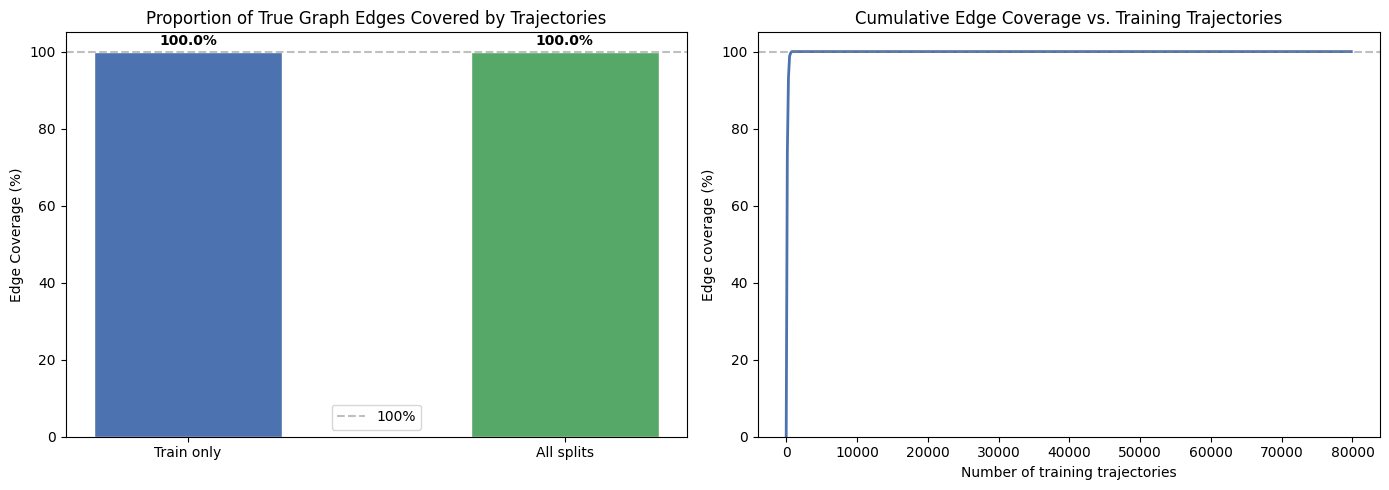

In [42]:
# --- Edge coverage visualization ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: coverage by split
splits = ['Train only', 'All splits']
coverages = [train_coverage * 100, all_coverage * 100]
colors = ['#4C72B0', '#55A868']

bars = axes[0].bar(splits, coverages, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Edge Coverage (%)')
axes[0].set_title('Proportion of True Graph Edges Covered by Trajectories')
axes[0].set_ylim(0, 105)
axes[0].axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='100%')
for bar, cov in zip(bars, coverages):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{cov:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].legend()

# Cumulative edge coverage as a function of number of training trajectories
covered = set()
coverage_curve = []
sample_points = np.linspace(0, len(train_trajs), min(500, len(train_trajs)), dtype=int)
sample_set = set(sample_points)

for i, path in enumerate(train_trajs):
    for j in range(len(path) - 1):
        covered.add(make_edge(path[j], path[j + 1]))
    if i in sample_set:
        coverage_curve.append((i + 1, len(covered & true_edges) / len(true_edges) * 100))

xs, ys = zip(*coverage_curve)
axes[1].plot(xs, ys, color='#4C72B0', linewidth=2)
axes[1].set_xlabel('Number of training trajectories')
axes[1].set_ylabel('Edge coverage (%)')
axes[1].set_title('Cumulative Edge Coverage vs. Training Trajectories')
axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

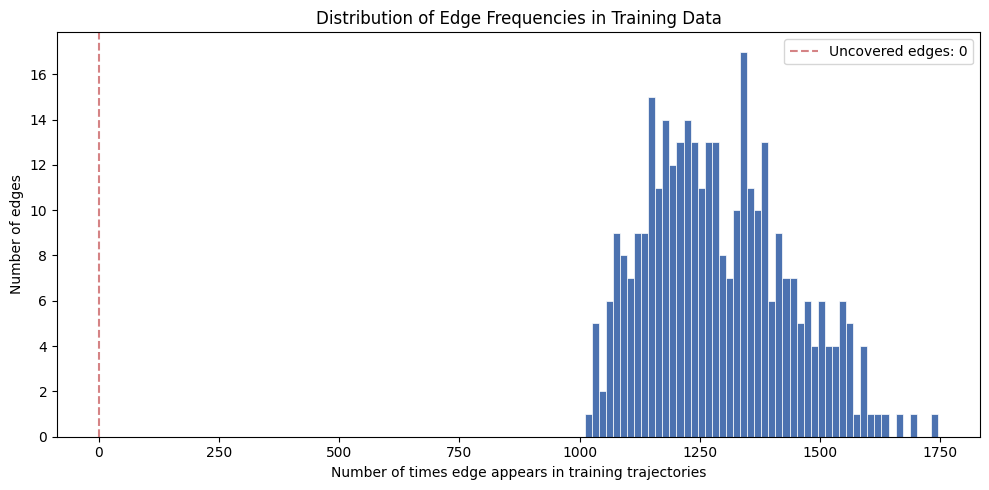

Edges never traversed in training: 0 / 341 (0.00%)
Mean edge frequency (among covered): 1289.17
Median edge frequency (among covered): 1273.0


In [43]:
# --- Per-edge frequency: how many times each true edge appears in training data ---

train_edge_counts = Counter()
for path in train_trajs:
    for i in range(len(path) - 1):
        e = make_edge(path[i], path[i + 1])
        if e in true_edges:
            train_edge_counts[e] += 1

# Edges with zero occurrences
zero_count = len(true_edges) - len(train_edge_counts)
freq_values = list(train_edge_counts.values()) + [0] * zero_count

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(freq_values, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of times edge appears in training trajectories')
ax.set_ylabel('Number of edges')
ax.set_title('Distribution of Edge Frequencies in Training Data')
ax.axvline(x=0.5, color='#C44E52', linestyle='--', alpha=0.7, label=f'Uncovered edges: {zero_count}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Edges never traversed in training: {zero_count} / {len(true_edges)} "
      f"({zero_count/len(true_edges)*100:.2f}%)")
print(f"Mean edge frequency (among covered): {np.mean(list(train_edge_counts.values())):.2f}")
print(f"Median edge frequency (among covered): {np.median(list(train_edge_counts.values())):.1f}")